# Bilateral Filter Evaluation Results

In [ ]:
import os

import matplotlib.pyplot as plt

from evaluate_utils import (
    read_model_results,
    plot_model_loss_all,
    read_performance_results,
    plot_performance_stages,
    compute_performance_speedup,
    print_frame_timing,
    read_quality_results,
    plot_quality_metrics_full,
    print_quality_metrics,
)
from plot_utils import set_plot_style, colors, set_legend_style

RESULTS_DIR = os.path.join('results', 'filter')
RADIANCE_DIR = os.path.join('..', 'data', 'radiance')
EXTINCTIONS = 80, 200, 1000

set_plot_style()

## Model

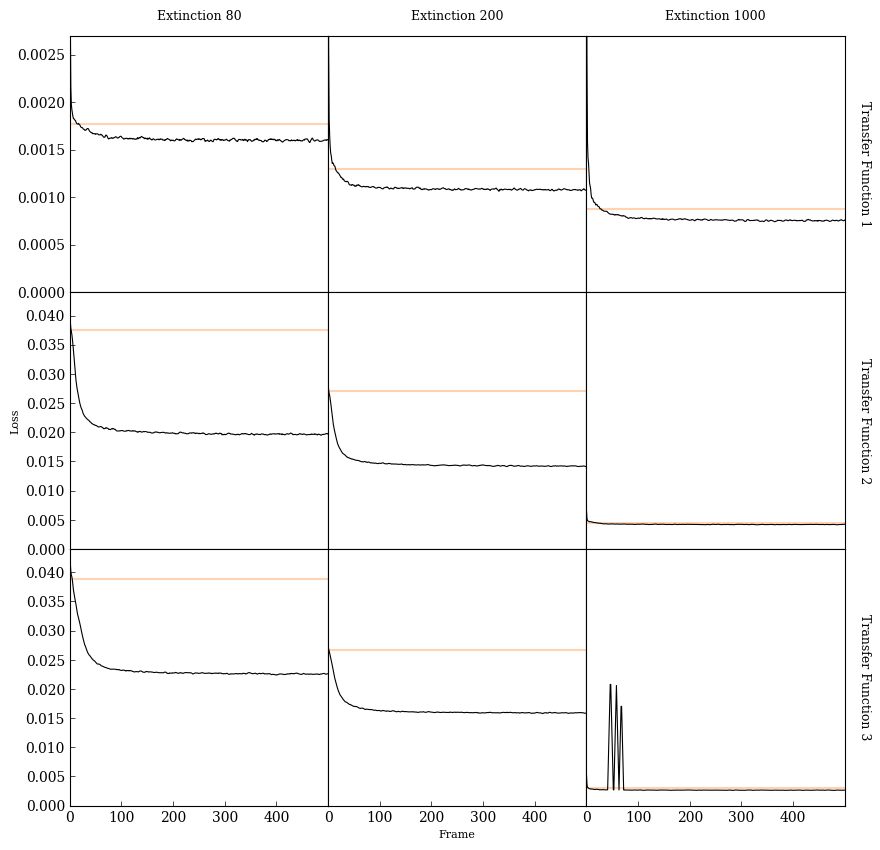

In [3]:
model_results = read_model_results(os.path.join(RESULTS_DIR, 'model'))
ylims = [(0, 0.0027), (0, 0.044), (0, 0.044)]
plot_model_loss_all(model_results, 'chameleon', ylims, show_legend=False)
plt.show()

## Performance

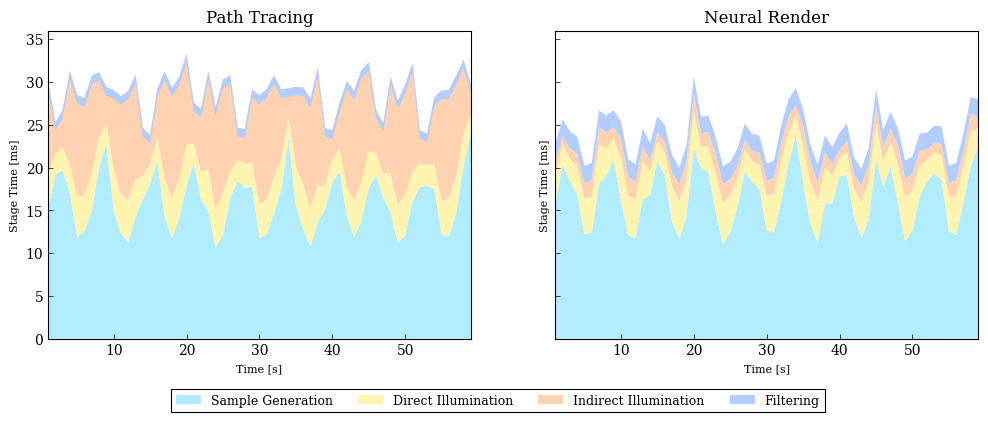

In [4]:
performance_results = {
    'path_tracing': read_performance_results(
        os.path.join(RESULTS_DIR, 'performance', 'path_tracing')
    ),
    'neural_render': read_performance_results(
        os.path.join(RESULTS_DIR, 'performance', 'neural_render')
    ),
}

example = 'chameleon', 1000
stage_cols = ['stage_sample_gen', 'stage_direct', 'stage_indirect', 'stage_filter']
stage_colors = [colors[5], colors[0], colors[2], colors[6]]
fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for i, subdir in enumerate(['path_tracing', 'neural_render']):
    plot_performance_stages(
        ax[i], performance_results[subdir], example, stage_cols, stage_colors
    )
    ax[i].set_title(subdir.replace('_', ' ').title())
    ax[i].set_xlim(1, 59)
    ax[i].set_xlabel('Time [s]')
    ax[i].set_ylabel('Stage Time [ms]')

handles, labels = ax[0].get_legend_handles_labels()
labels = [
    'Sample Generation',
    'Direct Illumination',
    'Indirect Illumination',
    'Filtering',
]
legend = fig.legend(
    handles, labels, ncol=4, bbox_to_anchor=(0.5, 0), loc='upper center'
)
set_legend_style(legend)
plt.show()

In [5]:
timings = compute_performance_speedup(performance_results)
print_frame_timing(timings)

Dataset              Ext.    Ours Frame Time      Ours FPS             PT Frame Time        PT FPS               Speedup
chameleon            80      51.26 ± 0.27         19.57 ± 0.10         50.21 ± 0.38         20.05 ± 0.15         0.98   
                     200     69.44 ± 0.38         14.45 ± 0.08         84.26 ± 0.75         11.98 ± 0.11         1.21   
                     1000    94.72 ± 0.92         10.67 ± 0.10         114.12 ± 0.91        8.83 ± 0.07          1.20   
csafe_heptane        80      15.08 ± 0.71         83.45 ± 3.28         6.98 ± 0.05          144.25 ± 1.09        0.46   
                     200     30.21 ± 0.10         33.14 ± 0.11         27.43 ± 0.52         40.10 ± 1.71         0.91   
                     1000    56.54 ± 0.30         17.75 ± 0.09         64.85 ± 0.48         15.52 ± 0.11         1.15   
marmoset_neurons     80      63.44 ± 0.64         15.96 ± 0.16         62.91 ± 0.77         16.19 ± 0.20         0.99   
                     200     80.

## Quality

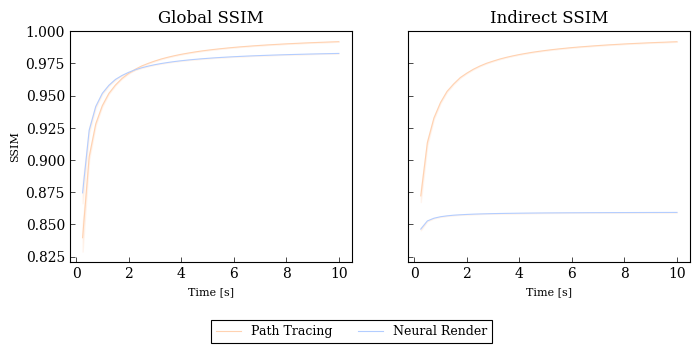

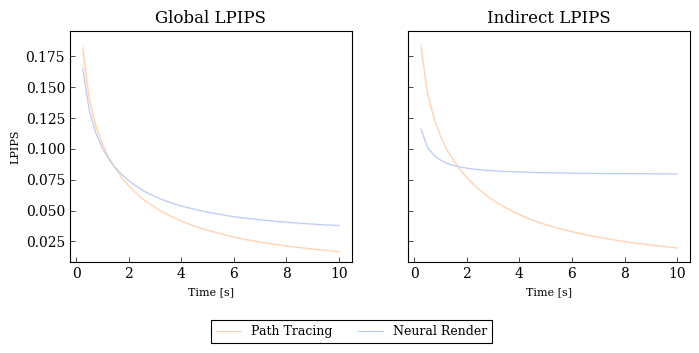

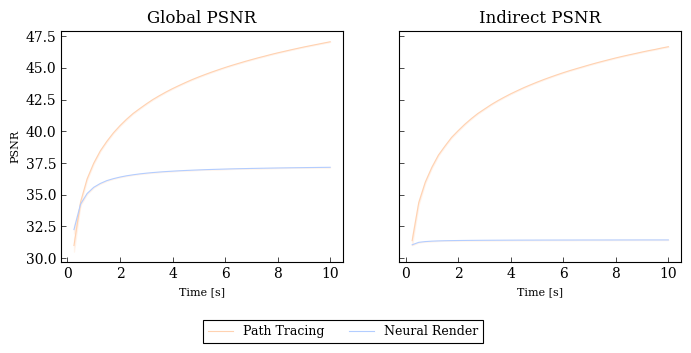

In [9]:
quality_results = read_quality_results(os.path.join(RESULTS_DIR, 'quality'))
plot_quality_metrics_full(quality_results, 'chameleon', 200, 3, 'ssim')
plot_quality_metrics_full(quality_results, 'chameleon', 200, 3, 'lpips')
plot_quality_metrics_full(quality_results, 'chameleon', 200, 3, 'psnr')

In [12]:
print_quality_metrics(quality_results, 'chameleon', 10, 'global')
print_quality_metrics(quality_results, 'chameleon', 10, 'indirect')
print()

print_quality_metrics(quality_results, 'csafe_heptane', 10, 'global')
print_quality_metrics(quality_results, 'csafe_heptane', 10, 'indirect')
print()

print_quality_metrics(quality_results, 'marmoset_neurons', 10, 'global')
print_quality_metrics(quality_results, 'marmoset_neurons', 10, 'indirect')
print()

Volume: chameleon (global)
Ext.  TF   SSIM PT            SSIM NR            LPIPS PT           LPIPS NR           PSNR PT         PSNR NR        
200   3    0.9919 ± 0.0000    0.9827 ± 0.0000    0.0168 ± 0.0001    0.0379 ± 0.0002    47.05 ± 0.01    37.16 ± 0.00
Volume: chameleon (indirect)
Ext.  TF   SSIM PT            SSIM NR            LPIPS PT           LPIPS NR           PSNR PT         PSNR NR        
200   3    0.9918 ± 0.0000    0.8593 ± 0.0000    0.0197 ± 0.0001    0.0797 ± 0.0001    46.66 ± 0.01    31.44 ± 0.00

Volume: csafe_heptane (global)
Ext.  TF   SSIM PT            SSIM NR            LPIPS PT           LPIPS NR           PSNR PT         PSNR NR        
200   3    0.9956 ± 0.0000    0.9820 ± 0.0000    0.0239 ± 0.0002    0.0351 ± 0.0001    51.04 ± 0.02    33.74 ± 0.00
Volume: csafe_heptane (indirect)
Ext.  TF   SSIM PT            SSIM NR            LPIPS PT           LPIPS NR           PSNR PT         PSNR NR        
200   3    0.9957 ± 0.0000    0.8225 ± 0.0000    0.0258